# Кластеризация


Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_palette('husl')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [16]:
# Загрузка данных
df = pd.read_csv('cirrhosis1.csv')
display(df.head())

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [17]:
df.shape

(312, 20)

Удаление идентификатора и разделение признаков и целевой переменной
Stage - это фактическая стадия заболевания (можно использовать для оценки качества)

In [19]:
cols_for_clusters = ['N_Days', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders',
                     'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
                     'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

X = df[cols_for_clusters].copy()
y_true = df['Stage']  # Истинные метки для оценки


In [20]:
# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nМасштабированные данные: {X_scaled.shape}")


Масштабированные данные: (312, 16)


# Метод K-Means

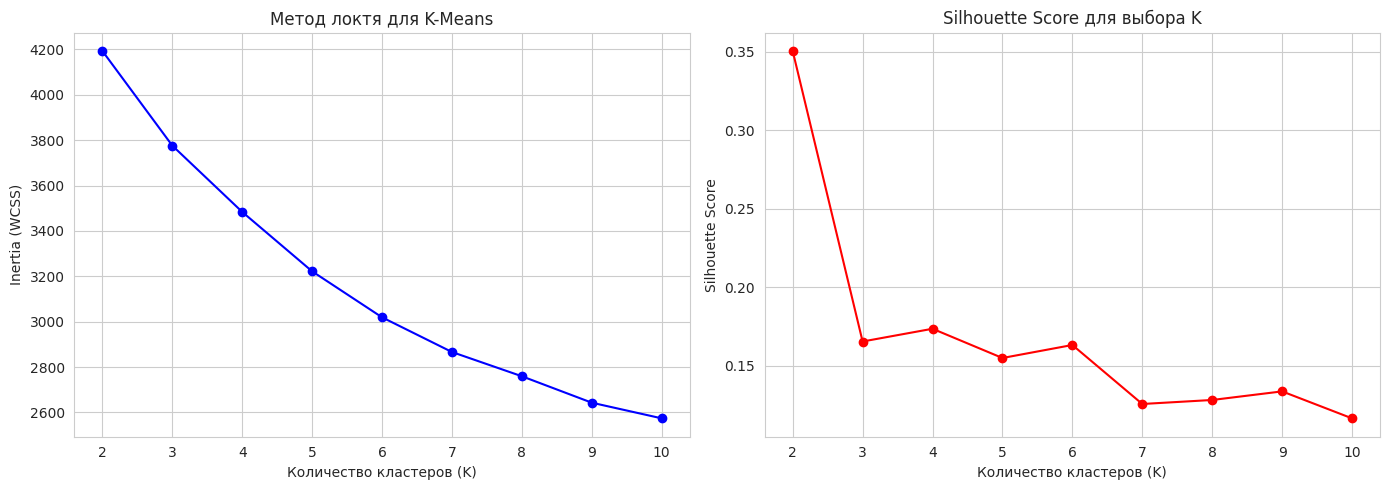

Оптимальное количество кластеров по Silhouette: 2


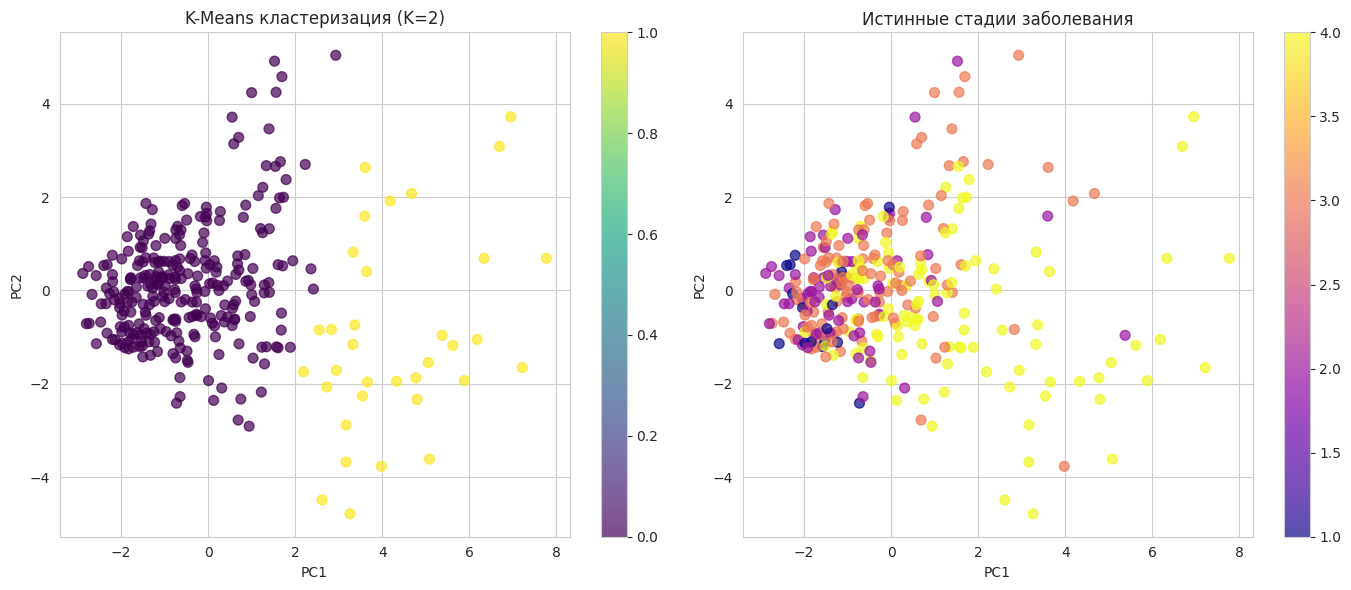

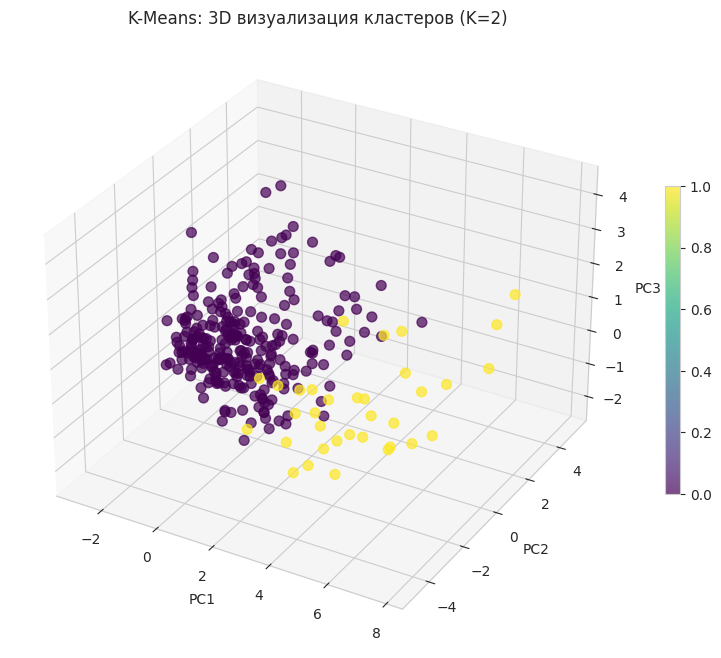


=== Оценка качества K-Means (K=2) ===
Silhouette Score: 0.351
Adjusted Rand Index (vs Stage): 0.005
Davies-Bouldin Index: 1.533


In [21]:
# Подбор оптимального количества кластеров для K-Means
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Визуализация метрик для выбора K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-')
axes[0].set_xlabel('Количество кластеров (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Метод локтя для K-Means')
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Количество кластеров (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score для выбора K')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Выбираем оптимальное K
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров по Silhouette: {optimal_k}")

# Применяем K-Means с оптимальным K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Визуализация результатов с помощью PCA для 2D/3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 2D визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Кластеры K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                          cmap='viridis', s=50, alpha=0.7)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means кластеризация (K={optimal_k})')
plt.colorbar(scatter1, ax=axes[0])

# Истинные метки (Stage) для сравнения
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true,
                          cmap='plasma', s=50, alpha=0.7)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Истинные стадии заболевания')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

# 3D визуализация
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter_3d = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                       c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'K-Means: 3D визуализация кластеров (K={optimal_k})')
plt.colorbar(scatter_3d, ax=ax, shrink=0.5)
plt.show()

# Оценка качества
print(f"\n=== Оценка качества K-Means (K={optimal_k}) ===")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"Adjusted Rand Index (vs Stage): {adjusted_rand_score(y_true, kmeans_labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, kmeans_labels):.3f}")

# Иерархическая кластеризация

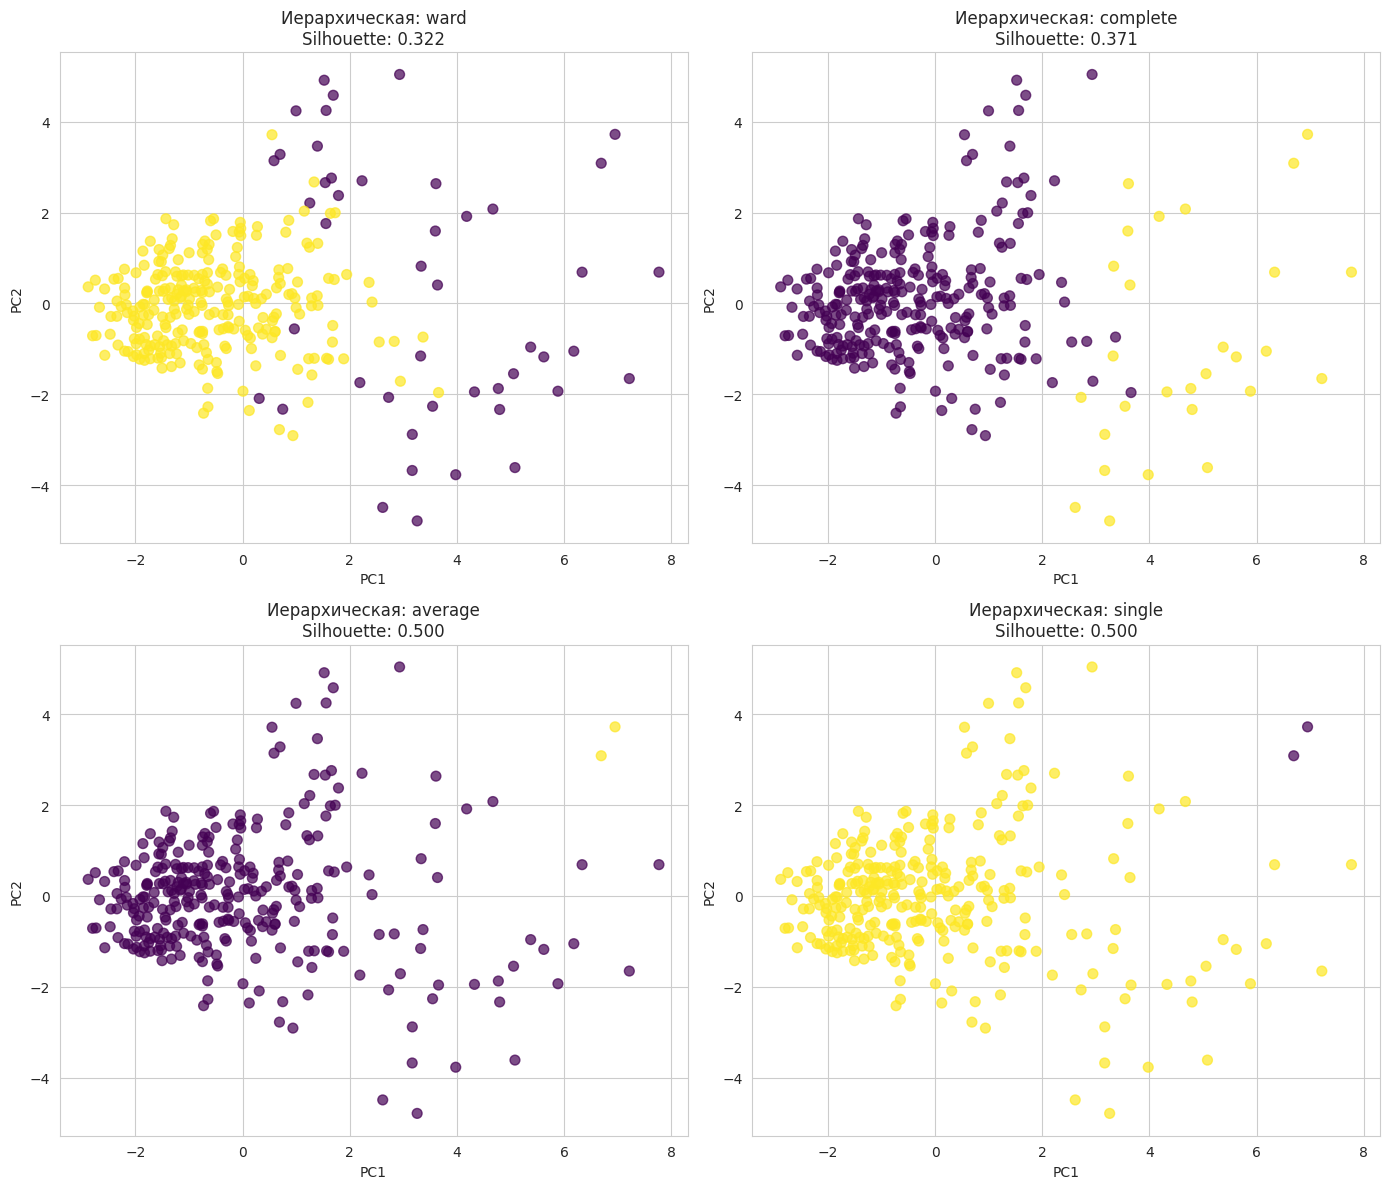


Лучший метод связи: average (Silhouette: 0.500)

=== Оценка качества Иерархической кластеризации ===
Silhouette Score: 0.500
Adjusted Rand Index (vs Stage): -0.001
Davies-Bouldin Index: 0.712


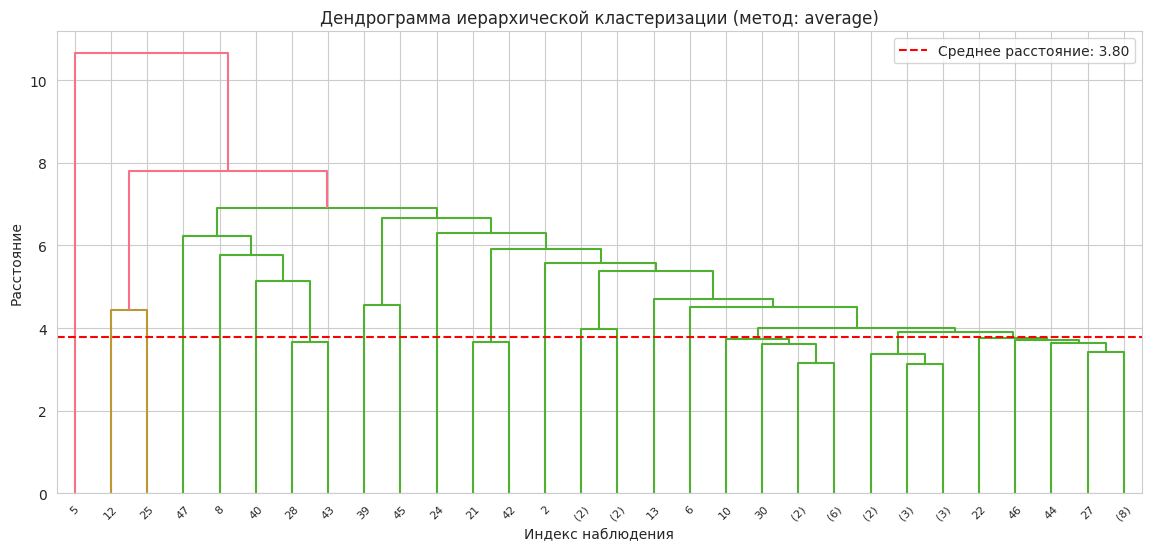

In [23]:
# Иерархическая кластеризация с разными методами связи
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

silhouette_hier = []

for idx, method in enumerate(linkage_methods):
    hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    hier_labels = hierarchical.fit_predict(X_scaled)
    silhouette_hier.append(silhouette_score(X_scaled, hier_labels))

    # Визуализация в пространстве PCA
    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels,
                     cmap='viridis', s=50, alpha=0.7)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].set_title(f'Иерархическая: {method}\nSilhouette: {silhouette_hier[-1]:.3f}')

plt.tight_layout()
plt.show()

# Выбираем лучший метод связи
best_method_idx = np.argmax(silhouette_hier)
best_method = linkage_methods[best_method_idx]
print(f"\nЛучший метод связи: {best_method} (Silhouette: {silhouette_hier[best_method_idx]:.3f})")

# Применяем лучшую иерархическую кластеризацию
hierarchical_best = AgglomerativeClustering(n_clusters=optimal_k, linkage=best_method)
hier_labels = hierarchical_best.fit_predict(X_scaled)

print(f"\n=== Оценка качества Иерархической кластеризации ===")
print(f"Silhouette Score: {silhouette_score(X_scaled, hier_labels):.3f}")
print(f"Adjusted Rand Index (vs Stage): {adjusted_rand_score(y_true, hier_labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, hier_labels):.3f}")

# Дендрограмма для первых 50 наблюдений
from scipy.cluster.hierarchy import dendrogram, linkage

# Берем подмножество для дендрограммы
sample_idx = np.random.choice(len(X_scaled), 50, replace=False)
X_sample = X_scaled[sample_idx]

linkage_matrix = linkage(X_sample, method=best_method)

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_font_size=8)
plt.title(f'Дендрограмма иерархической кластеризации (метод: {best_method})')
plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.axhline(y=np.mean(linkage_matrix[:, 2]), color='r', linestyle='--',
           label=f'Среднее расстояние: {np.mean(linkage_matrix[:, 2]):.2f}')
plt.legend()
plt.show()

# Гауссовы смеси (GMM)

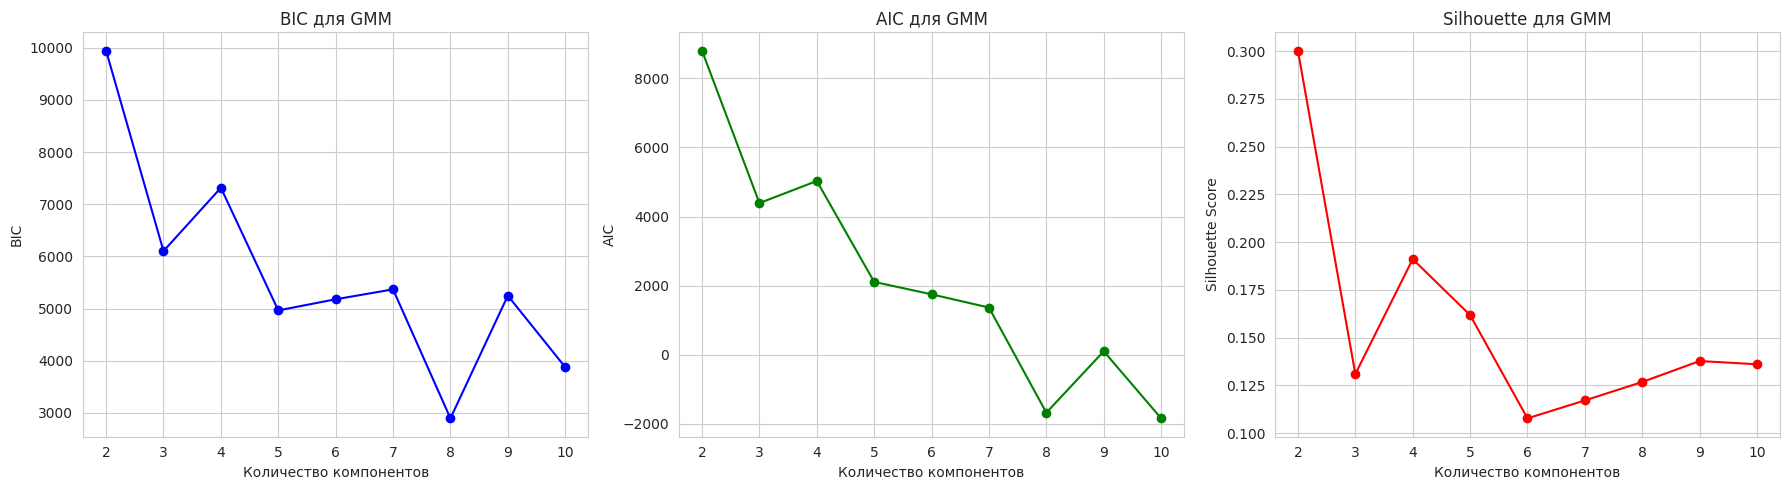

Оптимальное количество компонентов по BIC: 8


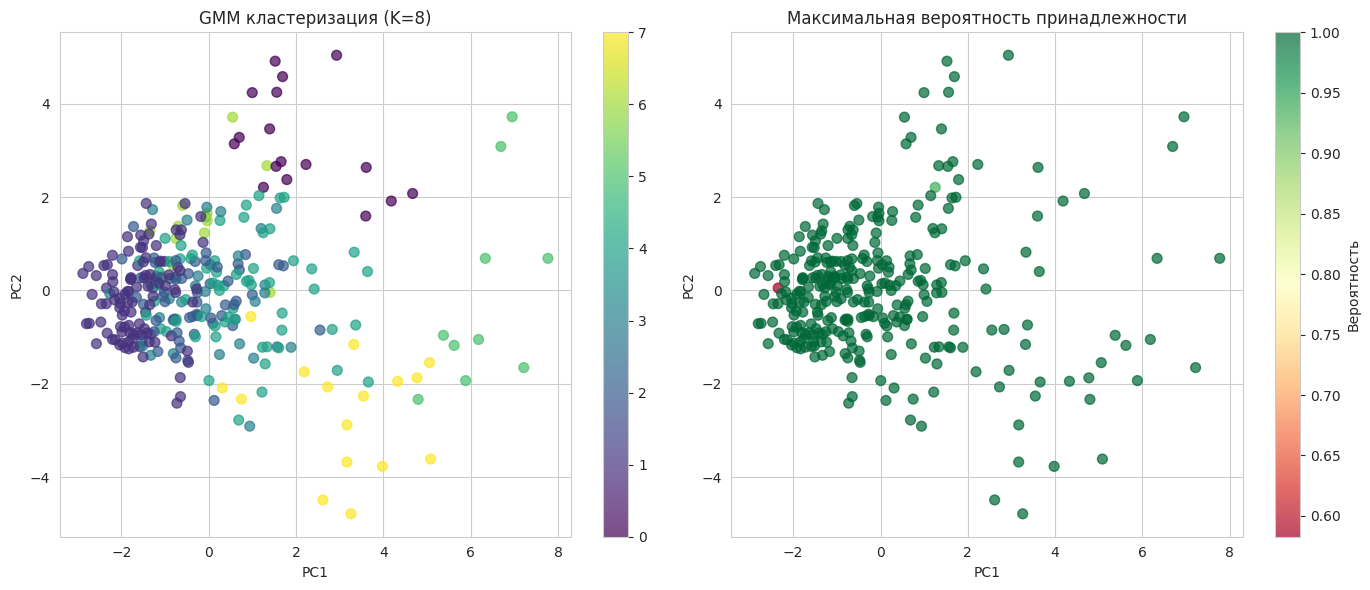


=== Оценка качества GMM ===
Silhouette Score: 0.127
Adjusted Rand Index (vs Stage): 0.047
Davies-Bouldin Index: 1.775
BIC: 2897.53, AIC: -1680.16


In [12]:
# Подбор оптимального количества компонентов для GMM
bic_scores = []
aic_scores = []
silhouette_gmm = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    labels = gmm.fit_predict(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    silhouette_gmm.append(silhouette_score(X_scaled, labels))

# Визуализация метрик для GMM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, bic_scores, 'bo-')
axes[0].set_xlabel('Количество компонентов')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC для GMM')
axes[0].grid(True)

axes[1].plot(k_range, aic_scores, 'go-')
axes[1].set_xlabel('Количество компонентов')
axes[1].set_ylabel('AIC')
axes[1].set_title('AIC для GMM')
axes[1].grid(True)

axes[2].plot(k_range, silhouette_gmm, 'ro-')
axes[2].set_xlabel('Количество компонентов')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette для GMM')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Выбираем оптимальное количество компонентов
optimal_gmm_k = k_range[np.argmin(bic_scores)]
print(f"Оптимальное количество компонентов по BIC: {optimal_gmm_k}")

# Применяем GMM
gmm = GaussianMixture(n_components=optimal_gmm_k, random_state=42, n_init=3)
gmm_labels = gmm.fit_predict(X_scaled)

# Визуализация результатов GMM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels,
                          cmap='viridis', s=50, alpha=0.7)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'GMM кластеризация (K={optimal_gmm_k})')
plt.colorbar(scatter1, ax=axes[0])

# Вероятности принадлежности к кластерам
gmm_proba = gmm.predict_proba(X_scaled)
max_proba = np.max(gmm_proba, axis=1)
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=max_proba,
                          cmap='RdYlGn', s=50, alpha=0.7)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Максимальная вероятность принадлежности')
plt.colorbar(scatter2, ax=axes[1], label='Вероятность')

plt.tight_layout()
plt.show()

print(f"\n=== Оценка качества GMM ===")
print(f"Silhouette Score: {silhouette_score(X_scaled, gmm_labels):.3f}")
print(f"Adjusted Rand Index (vs Stage): {adjusted_rand_score(y_true, gmm_labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, gmm_labels):.3f}")
print(f"BIC: {gmm.bic(X_scaled):.2f}, AIC: {gmm.aic(X_scaled):.2f}")

# DBSCAN

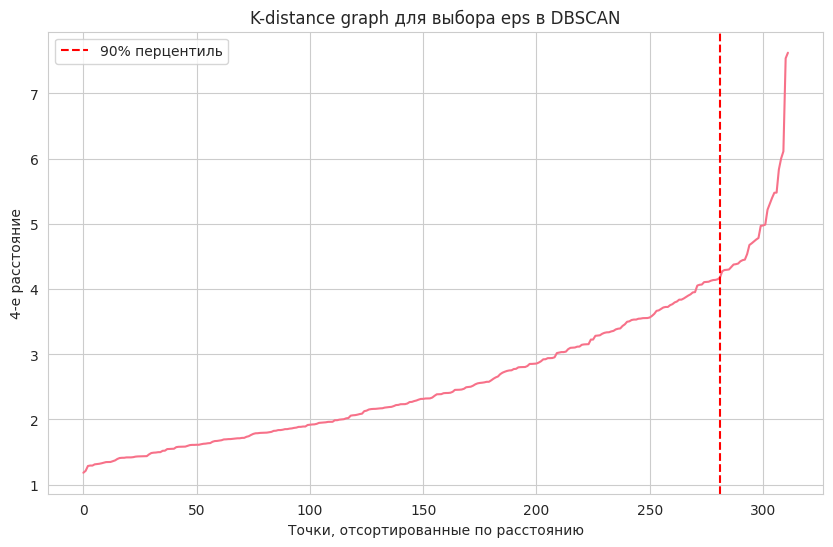

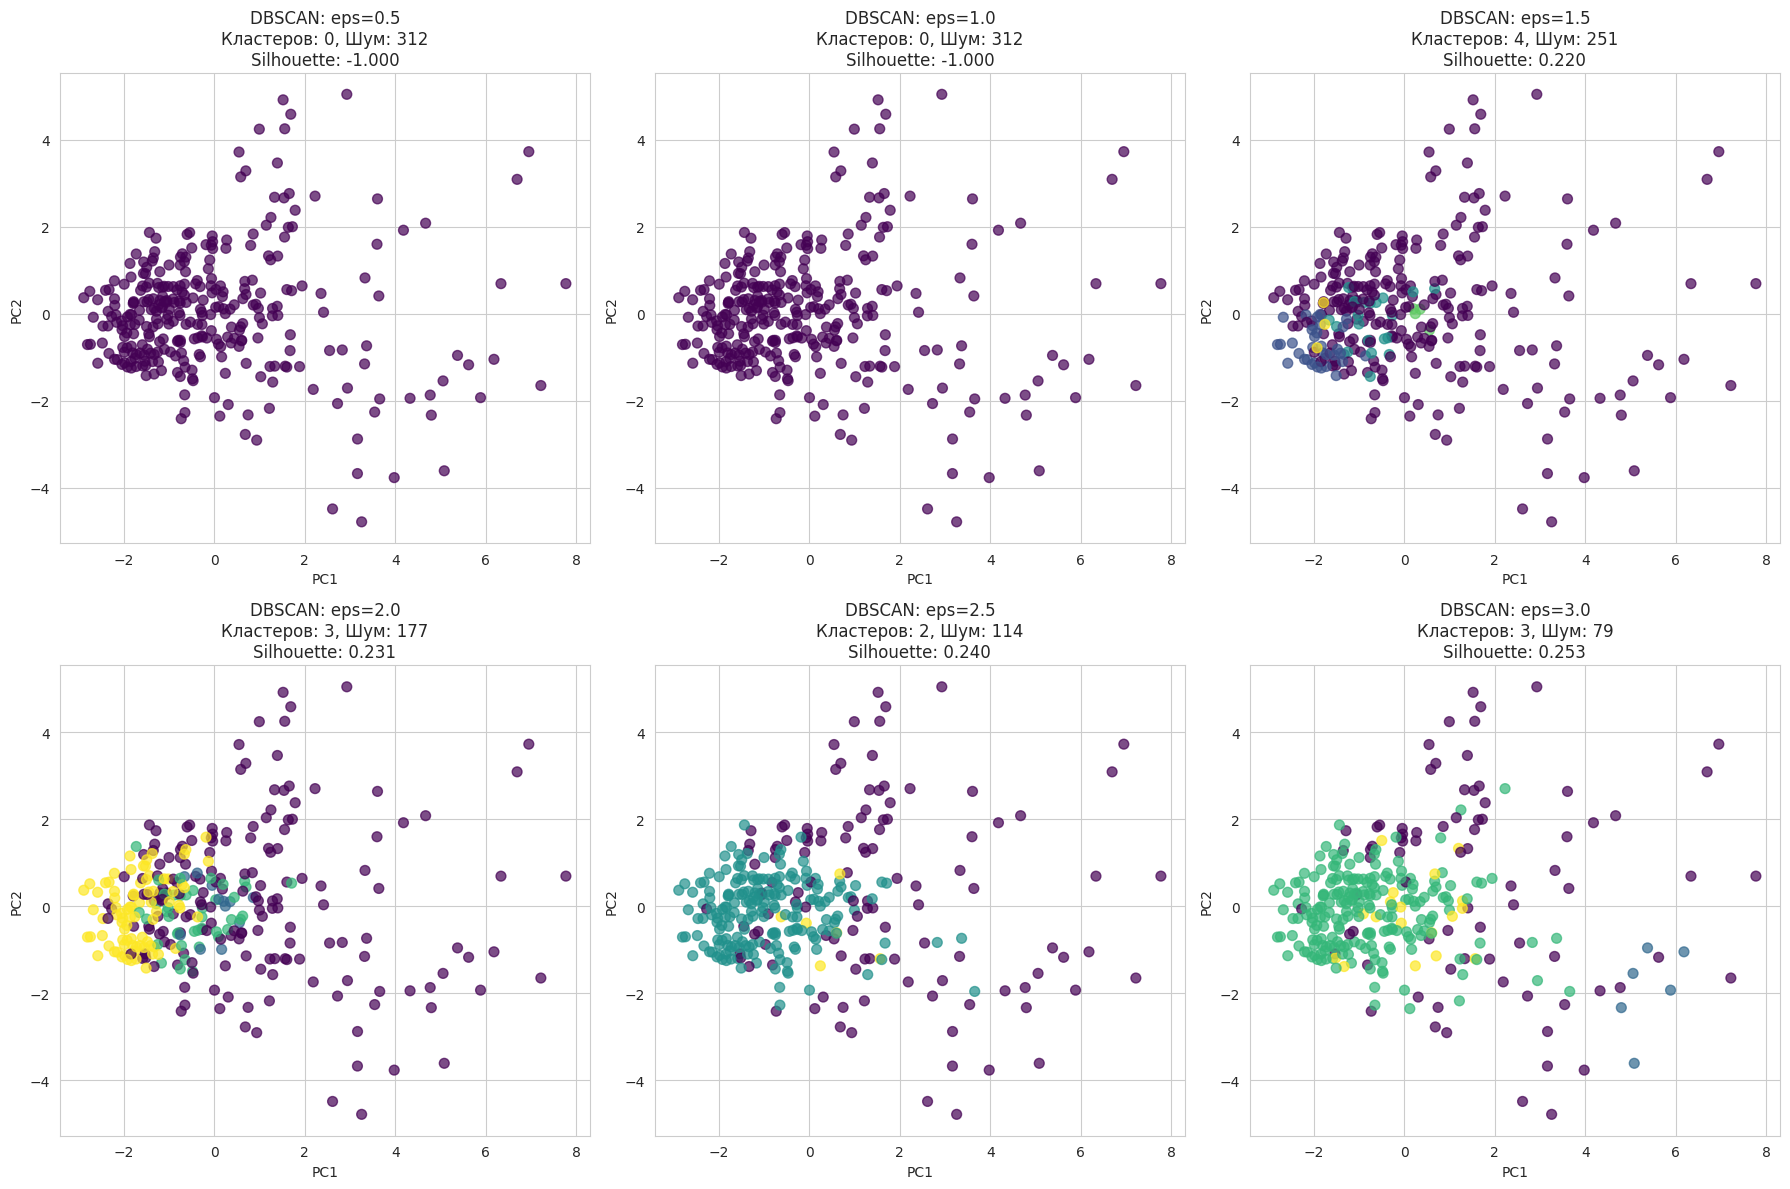


Лучшие параметры DBSCAN: eps=3.0
Кластеров: 3, Шум: 79

=== Оценка качества DBSCAN ===
Silhouette Score (без шума): 0.253
Adjusted Rand Index (vs Stage, без шума): 0.001


In [13]:
# Подбор параметров для DBSCAN с помощью k-distance graph
from sklearn.neighbors import NearestNeighbors

# График k-расстояний для выбора eps
k = 4  # min_samples обычно берут 2*dim или 4
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel(f'{k}-е расстояние')
plt.title('K-distance graph для выбора eps в DBSCAN')
plt.grid(True)
plt.axvline(x=len(distances)*0.9, color='r', linestyle='--', label='90% перцентиль')
plt.legend()
plt.show()

# Пробуем разные значения eps
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
dbscan_results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=k)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    # Подсчитываем статистику
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)

    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'labels': dbscan_labels
    })

    # Визуализация
    if n_clusters > 0:
        silhouette = silhouette_score(X_scaled[dbscan_labels != -1],
                                     dbscan_labels[dbscan_labels != -1])
    else:
        silhouette = -1

    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels,
                               cmap='viridis', s=50, alpha=0.7)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].set_title(f'DBSCAN: eps={eps}\nКластеров: {n_clusters}, Шум: {n_noise}\nSilhouette: {silhouette:.3f}')

plt.tight_layout()
plt.show()

# Выбираем лучший eps по Silhouette
best_dbscan = None
best_silhouette = -1

for result in dbscan_results:
    labels = result['labels']
    if len(set(labels)) > 1 and -1 in labels:
        # Есть кластеры и шум
        mask = labels != -1
        if mask.sum() > 1:
            sil = silhouette_score(X_scaled[mask], labels[mask])
            if sil > best_silhouette:
                best_silhouette = sil
                best_dbscan = result

if best_dbscan:
    print(f"\nЛучшие параметры DBSCAN: eps={best_dbscan['eps']}")
    print(f"Кластеров: {best_dbscan['n_clusters']}, Шум: {best_dbscan['n_noise']}")

    print(f"\n=== Оценка качества DBSCAN ===")
    mask = best_dbscan['labels'] != -1
    if mask.sum() > 1:
        print(f"Silhouette Score (без шума): {silhouette_score(X_scaled[mask], best_dbscan['labels'][mask]):.3f}")
        print(f"Adjusted Rand Index (vs Stage, без шума): {adjusted_rand_score(y_true[mask], best_dbscan['labels'][mask]):.3f}")
else:
    print("Не удалось найти подходящие параметры для DBSCAN")


=== Сводная таблица результатов ===


,Method,Silhouette,ARI,DB,n_clusters,n_noise
0,K-Means,0.351,0.005,1.533,2,NaN
1,Hierarchical,0.500,-0.001,0.712,2,NaN
2,GMM,0.127,0.047,1.775,8,NaN
3,DBSCAN,0.253,0.001,1.241,3,79.0


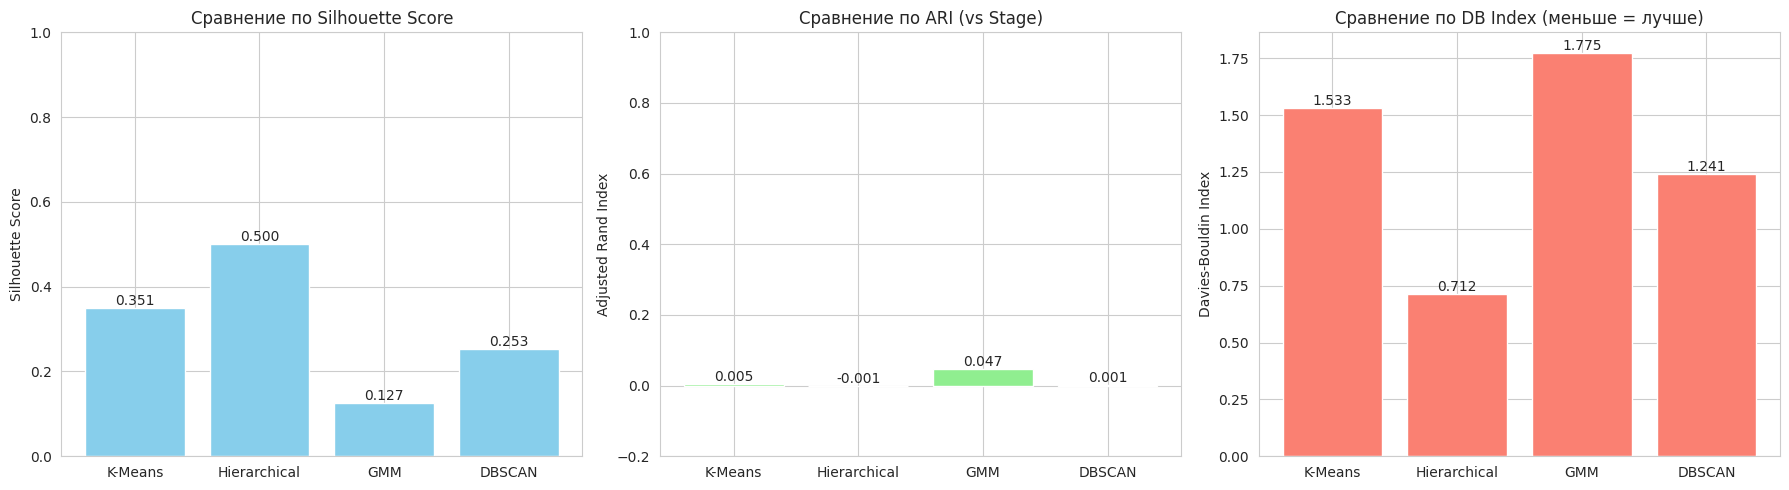

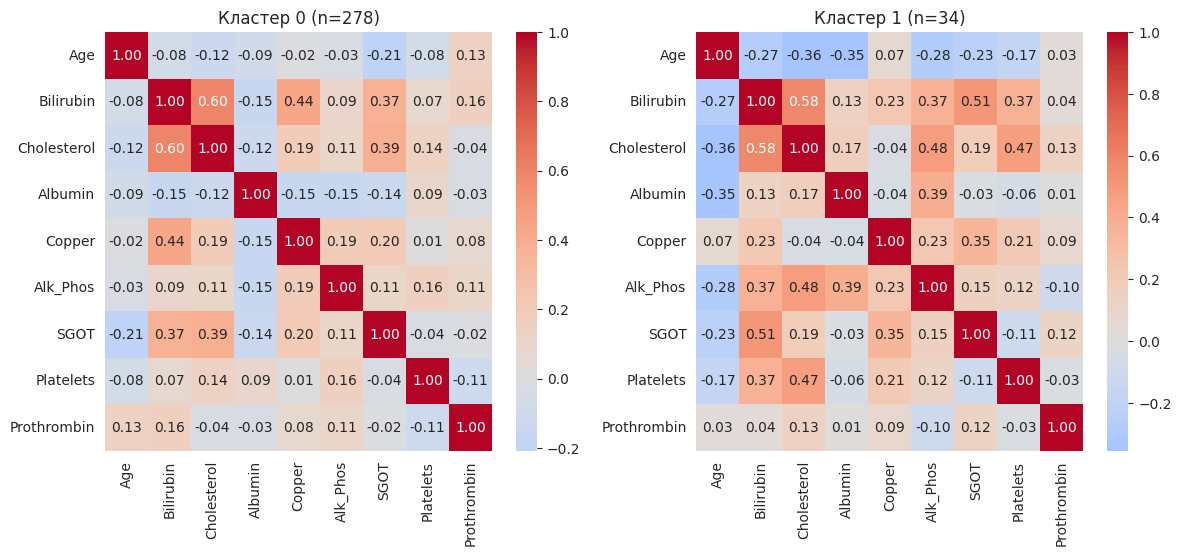

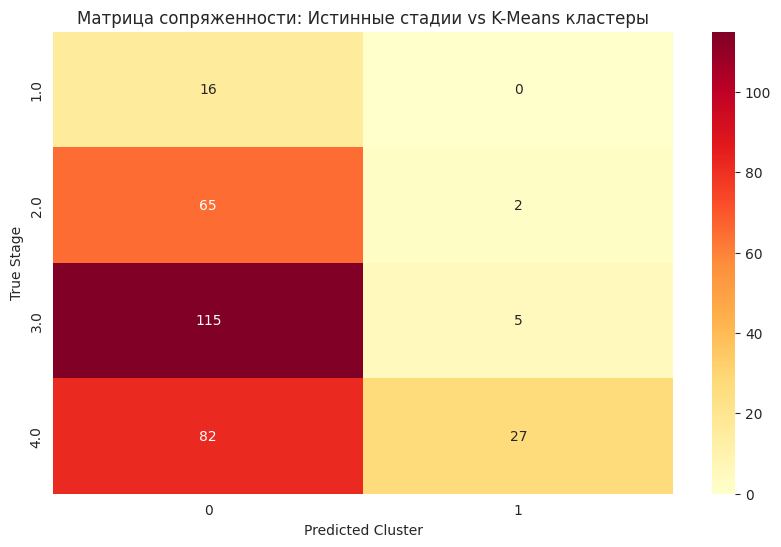

In [24]:
# Собираем результаты всех методов для сравнения
results = []

# K-Means
results.append({
    'Method': 'K-Means',
    'Silhouette': silhouette_score(X_scaled, kmeans_labels),
    'ARI': adjusted_rand_score(y_true, kmeans_labels),
    'DB': davies_bouldin_score(X_scaled, kmeans_labels),
    'n_clusters': optimal_k
})

# Hierarchical
results.append({
    'Method': 'Hierarchical',
    'Silhouette': silhouette_score(X_scaled, hier_labels),
    'ARI': adjusted_rand_score(y_true, hier_labels),
    'DB': davies_bouldin_score(X_scaled, hier_labels),
    'n_clusters': optimal_k
})

# GMM
results.append({
    'Method': 'GMM',
    'Silhouette': silhouette_score(X_scaled, gmm_labels),
    'ARI': adjusted_rand_score(y_true, gmm_labels),
    'DB': davies_bouldin_score(X_scaled, gmm_labels),
    'n_clusters': optimal_gmm_k
})

# DBSCAN (если найден)
if best_dbscan:
    mask = best_dbscan['labels'] != -1
    if mask.sum() > 1:
        results.append({
            'Method': 'DBSCAN',
            'Silhouette': silhouette_score(X_scaled[mask], best_dbscan['labels'][mask]),
            'ARI': adjusted_rand_score(y_true[mask], best_dbscan['labels'][mask]),
            'DB': davies_bouldin_score(X_scaled[mask], best_dbscan['labels'][mask]),
            'n_clusters': best_dbscan['n_clusters'],
            'n_noise': best_dbscan['n_noise']
        })

# Создаем DataFrame для визуализации
results_df = pd.DataFrame(results)
print("\n=== Сводная таблица результатов ===")
display(results_df.round(3))

# Визуализация сравнения методов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
bars1 = axes[0].bar(results_df['Method'], results_df['Silhouette'], color='skyblue')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Сравнение по Silhouette Score')
axes[0].set_ylim(0, 1)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                ha='center', va='bottom')

# Adjusted Rand Index
bars2 = axes[1].bar(results_df['Method'], results_df['ARI'], color='lightgreen')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('Сравнение по ARI (vs Stage)')
axes[1].set_ylim(-0.2, 1)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                ha='center', va='bottom')

# Davies-Bouldin Index (чем меньше, тем лучше)
bars3 = axes[2].bar(results_df['Method'], results_df['DB'], color='salmon')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Сравнение по DB Index (меньше = лучше)')
for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Heatmap корреляций признаков внутри кластеров (на примере K-Means)
plt.figure(figsize=(12, 10))
df_temp = X.copy()
df_temp['Cluster'] = kmeans_labels

# Выбираем числовые признаки для heatmap
numeric_cols = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
                'Alk_Phos', 'SGOT', 'Platelets', 'Prothrombin']

for cluster in range(optimal_k):
    cluster_data = df_temp[df_temp['Cluster'] == cluster][numeric_cols]
    if len(cluster_data) > 1:
        corr = cluster_data.corr()
        plt.subplot(2, 2, cluster + 1)
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title(f'Кластер {cluster} (n={len(cluster_data)})')

plt.tight_layout()
plt.show()

# Распределение истинных стадий по найденным кластерам (для K-Means)
plt.figure(figsize=(10, 6))
conf_matrix = pd.crosstab(y_true, kmeans_labels, rownames=['True Stage'],
                         colnames=['Predicted Cluster'])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Матрица сопряженности: Истинные стадии vs K-Means кластеры')
plt.show()



Выводы:
Лучший метод по Silhouette Score: Hierarchical (0.500)
Лучший метод по ARI: GMM (0.047)

Рекомендация: Для данного набора данных лучше всего подходит Hierarchical,
так как он показывает наилучшую компактность и разделимость кластеров.